In [1]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from torchdiffeq import odeint
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

sns.set(style="whitegrid")

In [2]:
class AccidentPreprocessor:
    def __init__(self):
        self.ordinal_encoder = OrdinalEncoder(handle_unknown='error')
        self.scaler = MinMaxScaler()

    def temporal_embedding(self, df):
        # keep it but original training script already used these
        if 'HOUR' in df.columns:
            df['HOUR_SIN'] = np.sin(2 * np.pi * df['HOUR'] / 24)
            df['HOUR_COS'] = np.cos(2 * np.pi * df['HOUR'] / 24)
        if 'DAY' in df.columns:
            df['DAY_SIN'] = np.sin(2 * np.pi * df['DAY'] / 31)
            df['DAY_COS'] = np.cos(2 * np.pi * df['DAY'] / 31)
        if 'MONTH' in df.columns:
            df['MONTH_SIN'] = np.sin(2 * np.pi * df['MONTH'] / 12)
            df['MONTH_COS'] = np.cos(2 * np.pi * df['MONTH'] / 12)
        return df

    def preprocess(self, df):
        df = df.copy()

        # fill NaNs for numeric columns
        numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
        cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

        df[numeric_cols] = df[numeric_cols].fillna(0)

        for col in cat_cols:
            df[col] = df[col].astype(str).fillna("missing")

        # apply temporal embedding
        df = self.temporal_embedding(df)

        # ordinal encode categorical cols (same behavior as training)
        if cat_cols:
            encoded = self.ordinal_encoder.fit_transform(df[cat_cols]).astype(int)
            # shift to make positive
            encoded = encoded + 1
            df[cat_cols] = encoded

        all_features = numeric_cols + cat_cols
        # If temporal embedding produced new columns (like HOUR_SIN), ensure present
        for extra in ['HOUR_SIN', 'HOUR_COS', 'DAY_SIN', 'DAY_COS', 'MONTH_SIN', 'MONTH_COS']:
            if extra in df.columns and extra not in all_features:
                all_features.append(extra)

        # final numeric scaling
        df[all_features] = self.scaler.fit_transform(df[all_features])

        return torch.FloatTensor(df[all_features].values), all_features


class AccidentDataset(Dataset):
    def __init__(self, csv_path, preprocessor: AccidentPreprocessor):
        df = pd.read_csv(csv_path, low_memory=False)
        X_tensor, self.feature_names = preprocessor.preprocess(df)
        self.X = X_tensor
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx]

In [3]:
class TemporalODEFunc(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim + 1, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, input_dim)
        self.relu = nn.ReLU()

    def forward(self, t, x):
        B, D = x.shape
        t_tensor = torch.ones(B, 1, device=x.device) * t
        x_with_time = torch.cat([x, t_tensor], dim=1)
        return self.fc2(self.relu(self.fc1(x_with_time)))


class NeuralODEAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, latent_dim)
        self.ode_func = TemporalODEFunc(latent_dim, hidden_dim)
        self.output_proj = nn.Linear(latent_dim, input_dim)

    def forward(self, x, time_points):
        z0 = self.input_proj(x)
        zt = odeint(self.ode_func, z0, time_points, method='dopri5')[-1]
        x_recon = self.output_proj(zt)
        return x_recon

In [4]:
def clean_state_dict(sd: dict):
    """Strip 'module.' prefix if present (DataParallel)."""
    new_sd = {}
    for k, v in sd.items():
        new_key = k
        if k.startswith("module."):
            new_key = k[len("module."):]
        new_sd[new_key] = v
    return new_sd

In [5]:
def load_model_from_checkpoint(ckpt_path, device, input_dim, hidden_dim=128, latent_dim=64):
    model = NeuralODEAutoencoder(input_dim, hidden_dim, latent_dim).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    sd = ckpt.get('model_state_dict', ckpt)
    sd = clean_state_dict(sd)
    model.load_state_dict(sd, strict=False)
    model.eval()
    return model

In [6]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import normalize
from scipy.spatial.distance import euclidean
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

In [7]:
def normalize_rows(arr):
    return normalize(arr, norm='l2')

In [8]:
def evaluate_quantitative_metrics(original, reconstructed):
    cos_sim = np.mean([cosine_similarity([o], [r])[0, 0] for o, r in zip(original, reconstructed)])
    dot_products = np.mean([np.dot(o, r) for o, r in zip(original, reconstructed)])
    l2_norm = np.mean([euclidean(o, r) for o, r in zip(original, reconstructed)])
    mse = mean_squared_error(original, reconstructed)

    original_norm = normalize_rows(original)
    reconstructed_norm = normalize_rows(reconstructed)
    ssim_vals = [ssim(o, r, data_range=1.0) for o, r in zip(original_norm, reconstructed_norm)]
    avg_ssim = np.mean(ssim_vals)

    pearsons = [pearsonr(original[:, i], reconstructed[:, i])[0] for i in range(original.shape[1])]
    avg_pearson = np.nanmean(pearsons)

    print("\n=== Quantitative Reconstruction Metrics ===")
    print(f"Cosine Similarity:        {cos_sim:.4f}")
    print(f"Dot Product:              {dot_products:.4f}")
    print(f"L2 Norm (Euclidean):      {l2_norm:.4f}")
    print(f"MSE:                      {mse:.6f}")
    print(f"SSIM:                     {avg_ssim:.4f}")
    print(f"Pearson Correlation:      {avg_pearson:.4f}")

In [9]:
def plot_heatmaps(original, reconstructed, sample_idx=0):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(original[sample_idx].reshape(1, -1), ax=axes[0], cmap='viridis', cbar=False)
    axes[0].set_title("Original Sample Heatmap")
    sns.heatmap(reconstructed[sample_idx].reshape(1, -1), ax=axes[1], cmap='viridis', cbar=False)
    axes[1].set_title("Reconstructed Sample Heatmap")
    plt.tight_layout()
    plt.show()

def plot_line_distribution(original, reconstructed, sample_idx=0):
    plt.figure(figsize=(12, 4))
    plt.plot(original[sample_idx], label='Original', marker='o')
    plt.plot(reconstructed[sample_idx], label='Reconstructed', marker='x')
    plt.title("Feature-wise Value Comparison")
    plt.xlabel("Feature Index")
    plt.ylabel("Normalized Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_error_vector(original, reconstructed, sample_idx=0):
    error_vector = np.abs(original[sample_idx] - reconstructed[sample_idx])
    plt.figure(figsize=(10, 3))
    plt.bar(range(len(error_vector)), error_vector, color='tomato')
    plt.title("Feature-wise Absolute Error")
    plt.xlabel("Feature Index")
    plt.ylabel("Error")
    plt.tight_layout()
    plt.show()

def plot_radar(original, reconstructed, sample_idx=0):
    categories = [f"F{i}" for i in range(original.shape[1])]
    values_orig = original[sample_idx].tolist() + original[sample_idx, :1].tolist()
    values_recon = reconstructed[sample_idx].tolist() + reconstructed[sample_idx, :1].tolist()
    categories += categories[:1]
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values_orig, linewidth=1.5, linestyle='solid', label='Original')
    ax.plot(angles, values_recon, linewidth=1.5, linestyle='dashed', label='Reconstructed')
    ax.fill(angles, values_orig, alpha=0.1)
    ax.fill(angles, values_recon, alpha=0.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories[:-1], fontsize=8)
    ax.set_title("Radar Plot of Feature Values")
    ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_19279/3635931215.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("Neural_ODE_Exp_model.pth", map_location=device)



=== Quantitative Reconstruction Metrics ===
Cosine Similarity:        0.8959
Dot Product:              18.7581
L2 Norm (Euclidean):      2.0682
MSE:                      0.047653
SSIM:                     0.7323
Pearson Correlation:      0.6961


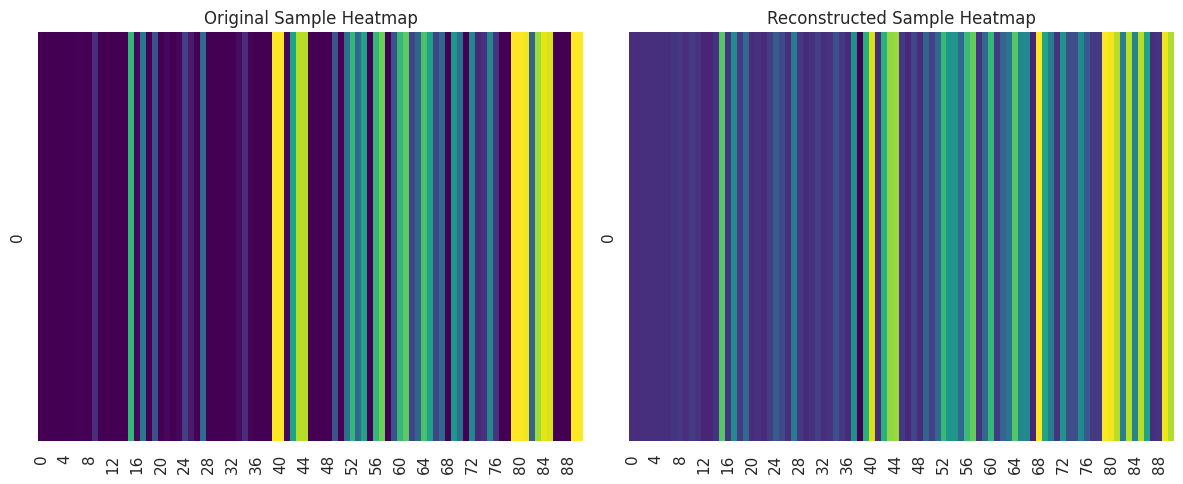

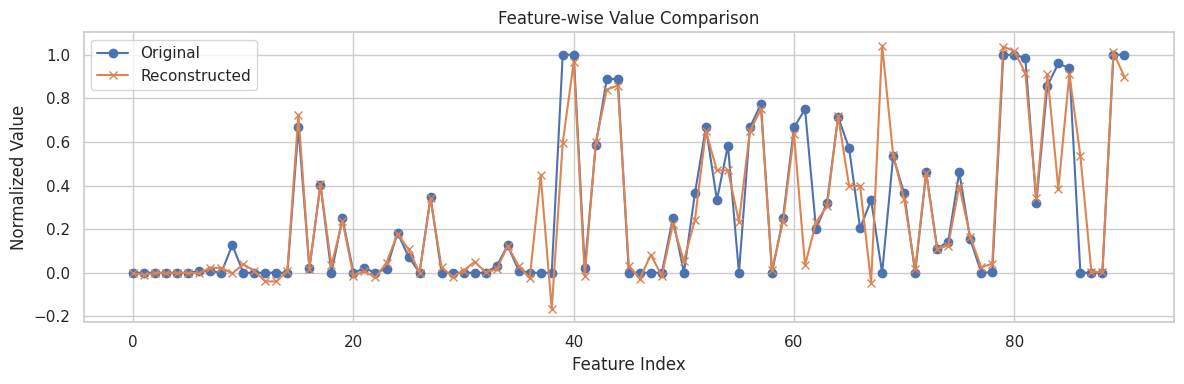

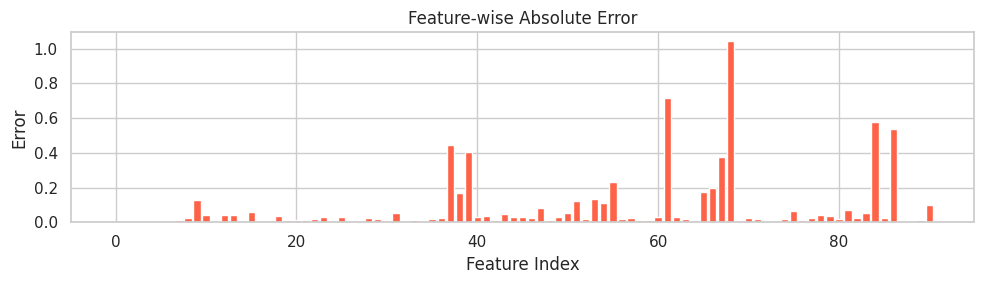

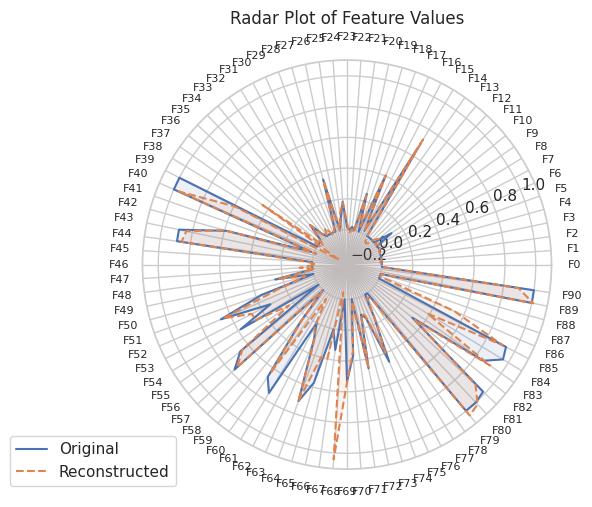

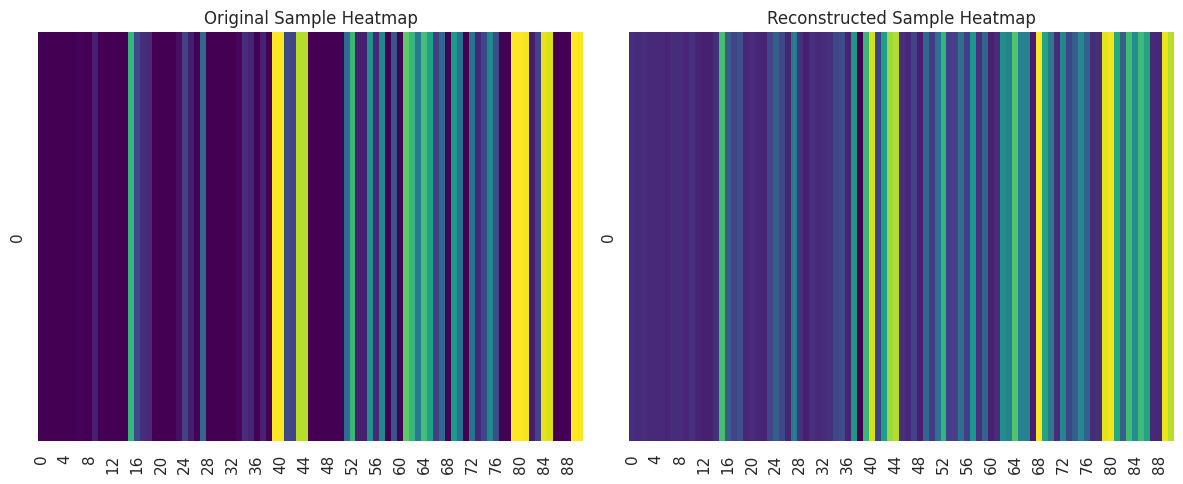

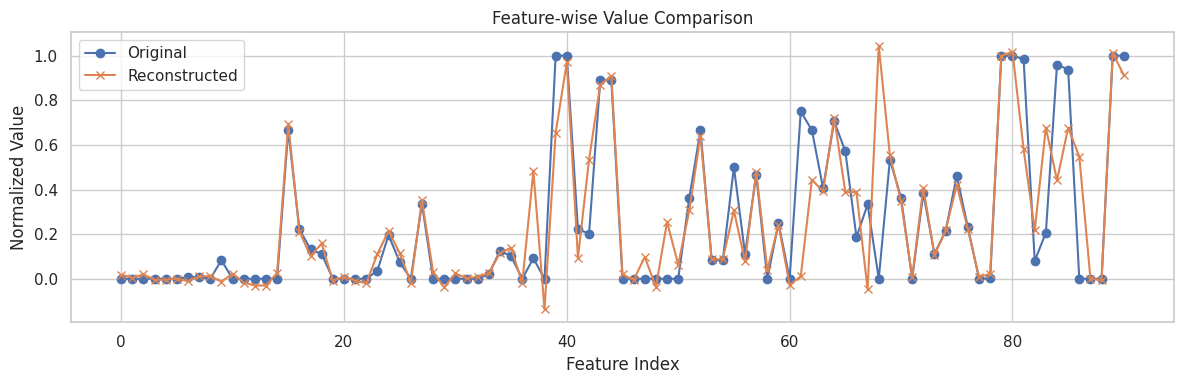

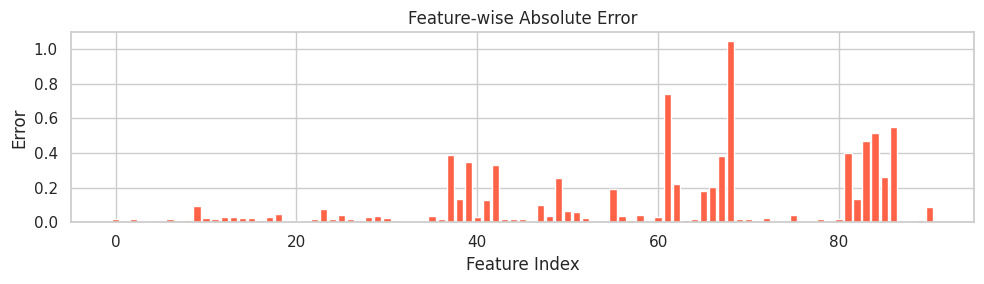

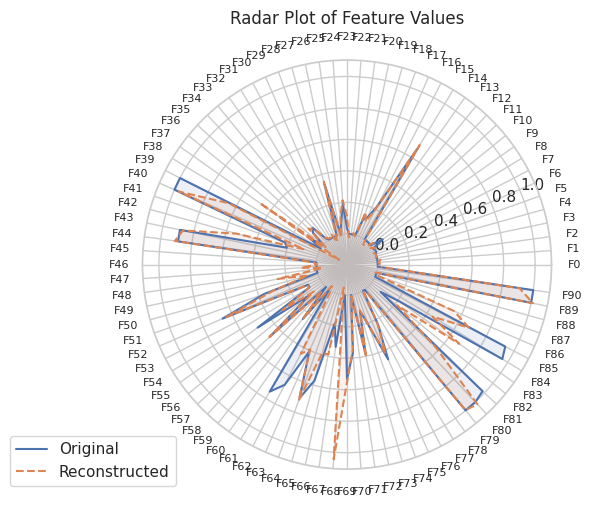

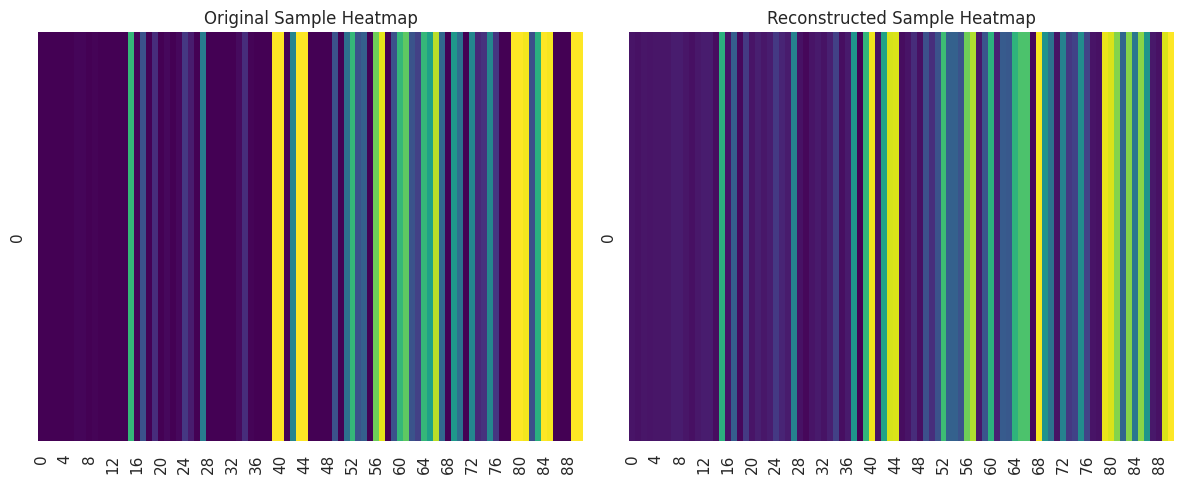

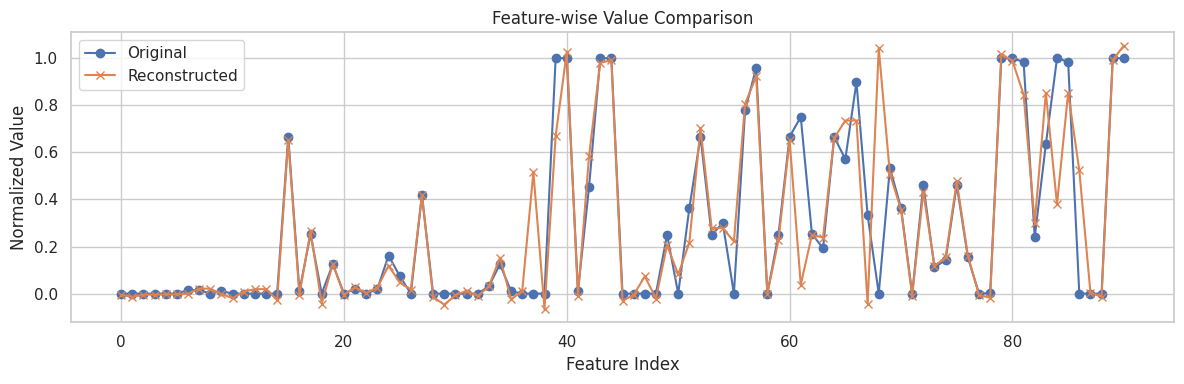

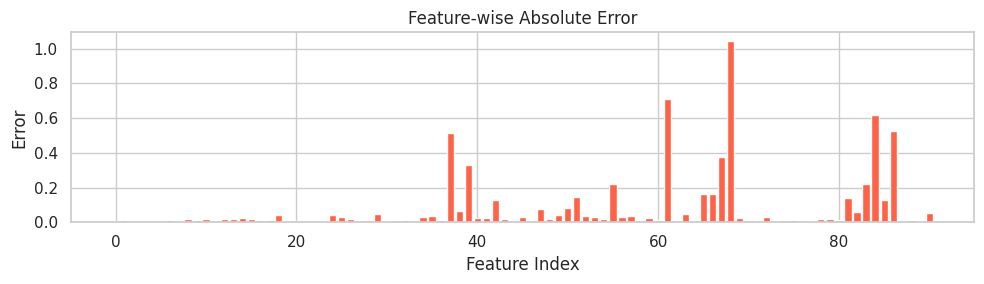

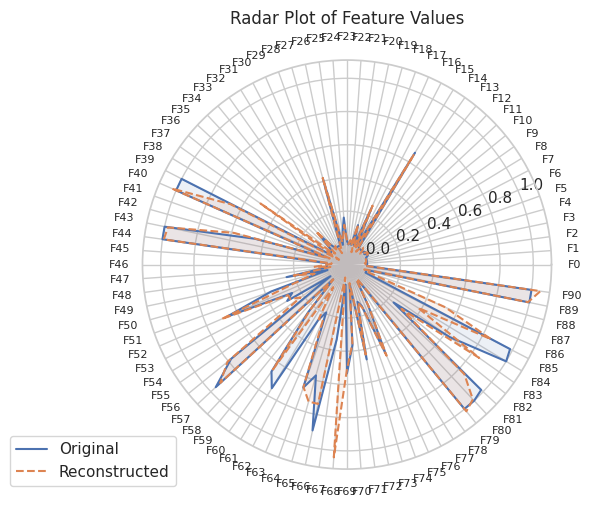

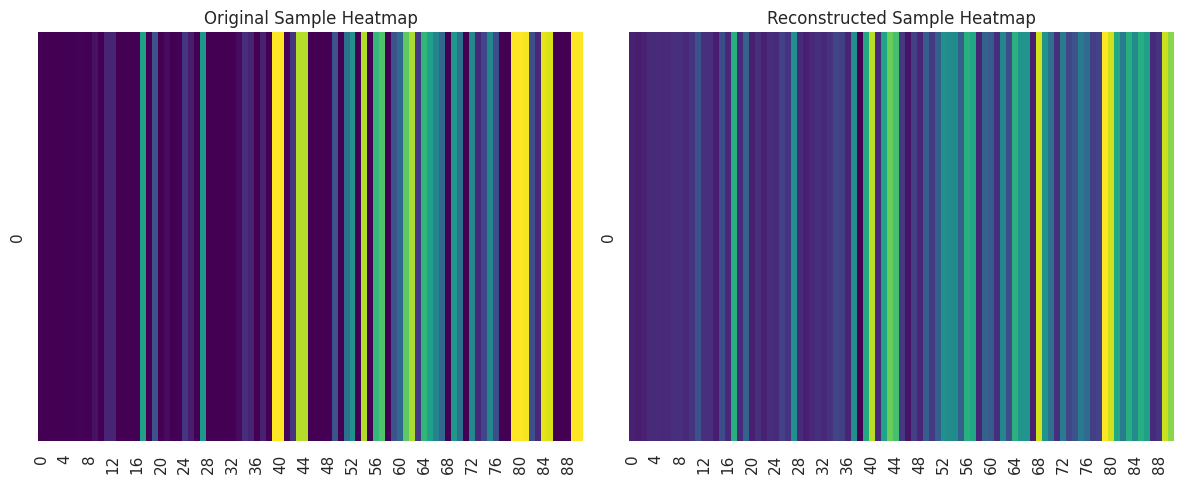

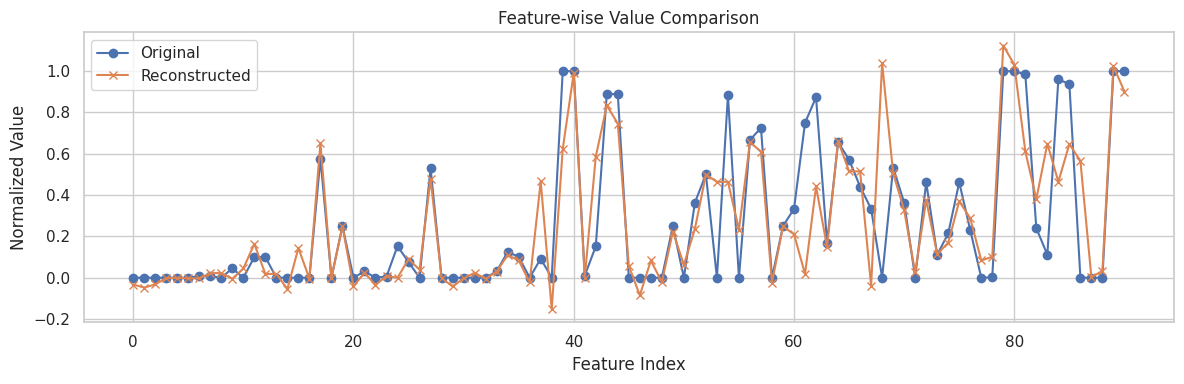

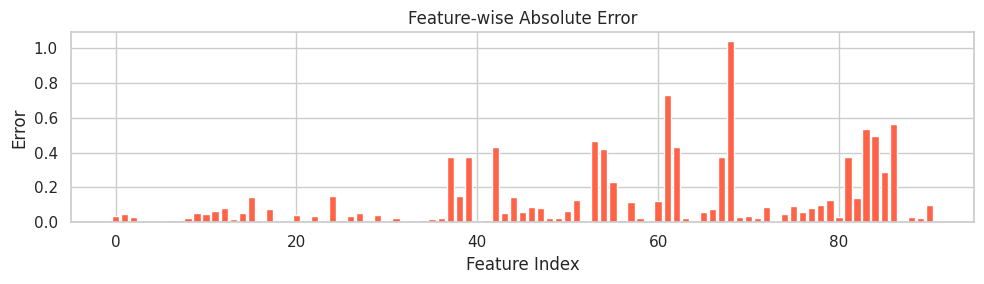

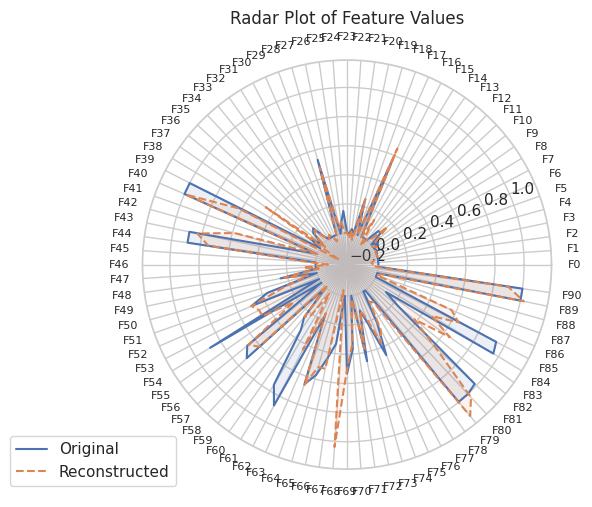

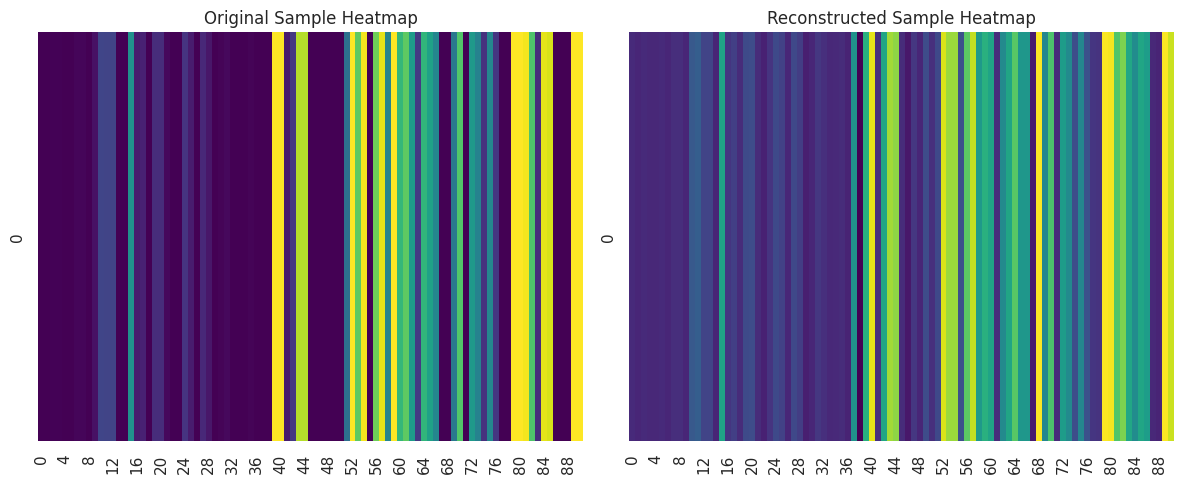

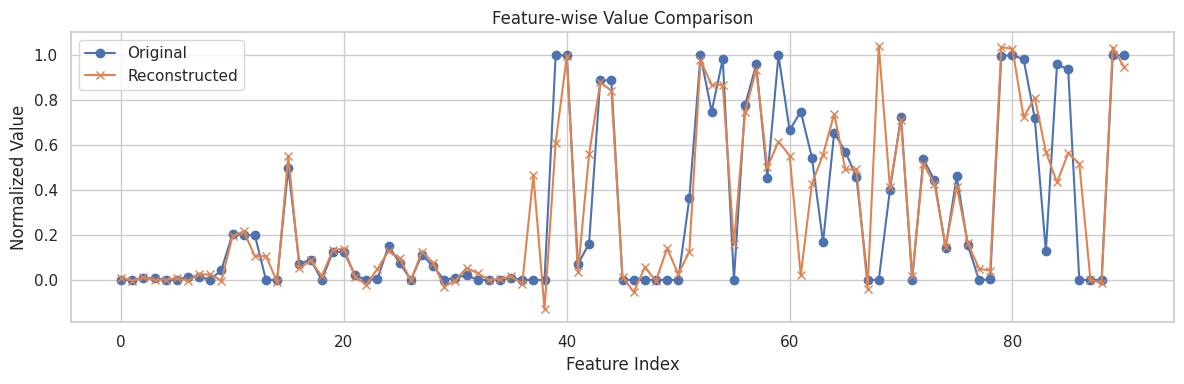

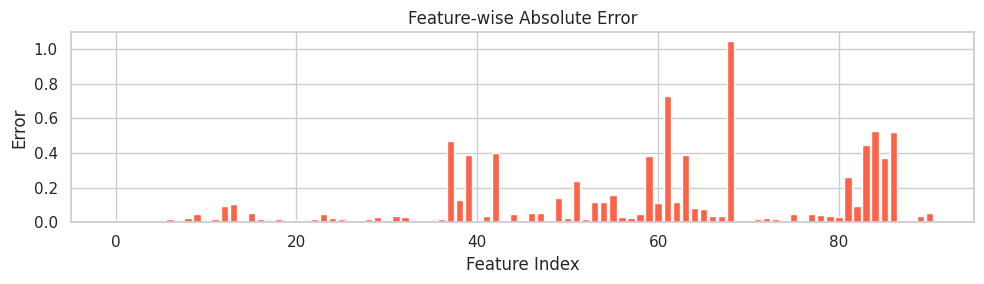

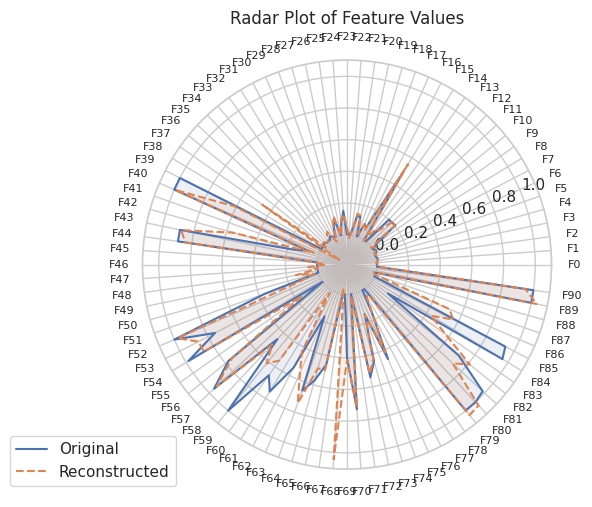

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

checkpoint = torch.load("Neural_ODE_Exp_model.pth", map_location=device)
input_dim = checkpoint['input_dim']

# Make sure you have your model class definitions in scope
model = NeuralODEAutoencoder(input_dim, checkpoint['hidden_dim'], checkpoint['latent_dim']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Load the dataset
preprocessor = AccidentPreprocessor()
dataset = AccidentDataset("raw_combined_accidents.csv", preprocessor)
X = dataset.X

if X.shape[1] > input_dim:
    # Keep only the first `expected_features` columns in the same order as training
    X = X[:, :input_dim]
elif X.shape[1] < input_dim:
    raise ValueError(f"Not enough features: got {X.shape[1]}, expected {input_dim}")

data_tensor = X.to(device)
if data_tensor.shape[1] != checkpoint['input_dim']:
    raise ValueError(f"Feature mismatch: model expects {checkpoint['input_dim']} features, "
                     f"but got {data_tensor.shape[1]}. Check preprocessing pipeline.")

# Forward pass
time_points = torch.linspace(0, 1, 2).to(device)
with torch.no_grad():
    reconstructed_tensor = model(data_tensor, time_points)

# Convert to numpy for metrics
original_np = data_tensor.cpu().numpy()
reconstructed_np = reconstructed_tensor.cpu().numpy()

# === Run Quantitative Metrics ===
evaluate_quantitative_metrics(original_np, reconstructed_np)

# === Run Qualitative Plots (first 3 examples) ===
for idx in range(5):
    plot_heatmaps(original_np, reconstructed_np, sample_idx=idx)
    plot_line_distribution(original_np, reconstructed_np, sample_idx=idx)
    plot_error_vector(original_np, reconstructed_np, sample_idx=idx)
    plot_radar(original_np, reconstructed_np, sample_idx=idx)